![imagen](img/python.jpg)

## Session 11: SQL Databases and SQL Alchemy

We will work with SQL databases.

**SQL Alchemy** is the most popular library to work with SQL databases in Python.<br>
It supports *async* and it has two parts:

- **SQL Alchemy Core**: to read/write data to/from SQL Databases
- **SQL Alchemy ORM**: abstraction over SQL concepts 

It is useful to use the ORM approach, because **tables and columns are Python objects**!

We install in the virtual environment the **sqlalchemy** library:

```bash
pip install "sqlalchemy[asyncio,mypy]"
```

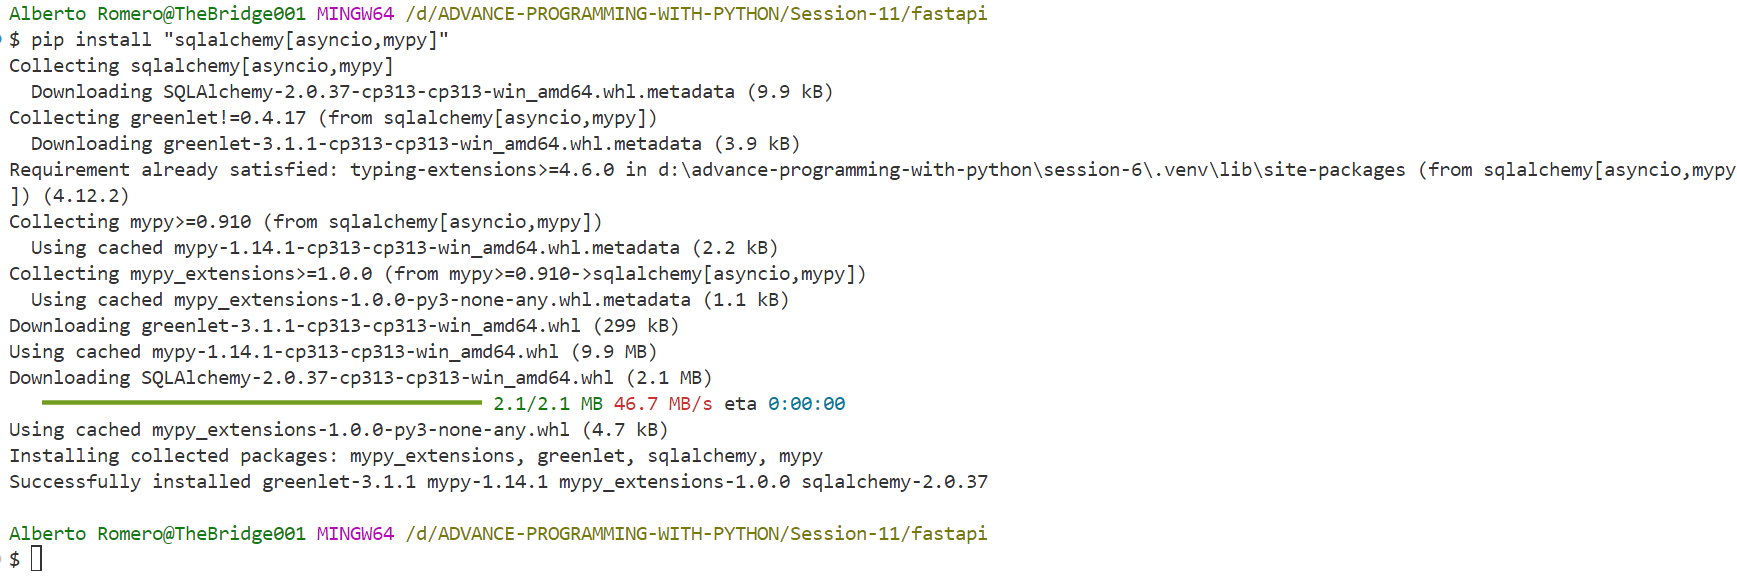

We will need async drivers that will depend on the database engine:

* PostgreSQL:&nbsp;&nbsp;&nbsp;&nbsp;`pip install asyncpg`
* MySQL:&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`pip install aiomysql`
* SQLite:&nbsp;&nbsp;&nbsp;&nbsp; `pip install aiosqlite`

We will use SQLite in this session, so you can install the driver for the SQLite engine.

The structure of a SQL Alchemy project is the following one:

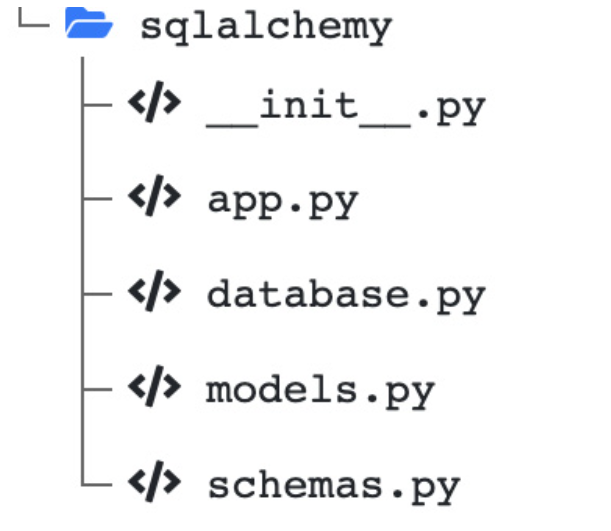

#### 11.1 ORM Models  (Object Relational Mapper)

An ORM model is a Python class whose attributes represent the columns of a SQL table.<br>
The entities of the database will be instances of this class.

Under the hood, the role of SQLAlchemy ORM is to link this Python object and the row in the database.

```python
from datetime import datetime

from sqlalchemy import DateTime, Integer, String, Text
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column


class Base(DeclarativeBase):
    pass


class Post(Base):
    __tablename__ = "posts"  # the table

    id: Mapped[int] = mapped_column(
        Integer, primary_key=True, autoincrement=True
    )  # column id, is primary key and has autoincrement
    publication_date: Mapped[datetime] = mapped_column(
        DateTime, nullable=False, default=datetime.now
    )  # column publication_date, cannot be null, default value is now
    title: Mapped[str] = mapped_column(String(255), nullable=False)  # a short text
    content: Mapped[str] = mapped_column(Text, nullable=False)  # a long text
```

#### 11.2 Pydantic models

We need Pydantic models to validate the data coming in and out of the FastAPI application.<br>
In an ORM context, <u> they will help us go back and forth with the ORM model.</u><br>


We use Pydantic models to validate and serialize the data, **but the database communication will be done with the ORM model.**

To avoid confusion, we’ll now refer to Pydantic models as **schemas**.<br>
When we talk about models, we’ll be referring to the **ORM model**.

Note: Not to be confused with Machine Learning models.

```python
from datetime import datetime

from pydantic import BaseModel, Field

# Pydantic for the schemas


class PostBase(BaseModel):
    title: str
    content: str
    publication_date: datetime = Field(
        default_factory=datetime.now
    )  # default_factory to initiate the time by default

    class Config:  # Config subclass
        # from_attributes = False would use Pydantic parsing data from dictionaries
        # example: d["title"]
        # from_attributes = True would use Pydantic parsing data using dot notation
        # example: o.title
        from_attributes = True


# To modify the title and content of a post
class PostPartialUpdate(BaseModel):
    title: str | None = None
    content: str | None = None


# To create a post we need PostBase like it is
class PostCreate(PostBase):
    pass


# To post a post we include an id (not decided by the user)
class PostRead(PostBase):
    id: int
```


#### 11.3 Connection to a database

We have the ORM model and the Pydantic schemas.<br>
Now we want to connect the FastAPI app and the database engine.<br>

We create a database.py module where we’ll put the objects we need for this purpose.

```python
from collections.abc import AsyncGenerator

from sqlalchemy.ext.asyncio import AsyncSession, async_sessionmaker, create_async_engine

from fastapi.sqlalchemy.models import Base

DATABASE_URL = "sqlite+aiosqlite:///fastapi_sqlalchemy.db"


# the engine is an object that will manage the connection to the database
engine = create_async_engine(DATABASE_URL)
async_session_maker = async_sessionmaker(
    engine, expire_on_commit=False
)  # this returns a function to generate sessions


# each HTTP request yields a fresh session that is closed when the request is answered
# That's why we need a generator

# *with* keyword is a context manager
# objects that need a setup logic before being used and a teardown logic when they are not used anymore
# like when we want to open a file, write and close the file

# *yield* keyword makes sure that the session remains open till the end of the request
# *return* would close immediately

# get_async_session is a dependency, FastAPI makes it very easy to swap it with another function
# this is helpful for testing!


async def get_async_session() -> AsyncGenerator[AsyncSession, None]:
    async with async_session_maker() as session:
        yield session


# we will create all the tables in the beginning
# simple approach but enough for our goal


async def create_all_tables():
    async with engine.begin() as conn:
        await conn.run_sync(Base.metadata.create_all)

```


#### 11.4 Creating objects

We want to insert new objects in our database.<br>
We have to:
1.    take a **Pydantic schema** as input,
2.    transform it into a **SQLAlchemy model**
3.    save it in the **database**

The whole code is in app.py

```python
@app.post(
    "/posts", response_model=schemas.PostRead, status_code=status.HTTP_201_CREATED
)
async def create_post(
    post_create: schemas.PostCreate, session: AsyncSession = Depends(get_async_session)
) -> Post:
    post = Post(**post_create.model_dump())
    session.add(post)
    await session.commit()

    return post
```

In [ ]:
# endpoint POST /posts
# input post_create with type hint schemas.PostCreate (Pydantic)
# We inject a fresh SQLAlchemy session with the dependency get_async_session

# We create a Post object (ORM Model)
# add it to memory
# commit it to write it in the database (async)

# We return Post (ORM Model)
# How can FastAPI know how to handle this returned ORM Model when we would expect a Pydantic object??
# response_model = schemas.PostRead !!
# And that's why we did orm_mode = True before!


#### 11.5 Listing objects

To list all the objects:

```python
@app.get("/posts", response_model=list[schemas.PostRead])
async def list_posts(
    pagination: tuple[int, int] = Depends(pagination),
    session: AsyncSession = Depends(get_async_session),
) -> Sequence[Post]:
    skip, limit = pagination
    select_query = select(Post).offset(skip).limit(limit)
    result = await session.execute(select_query)

    return result.scalars().all()
```


In [ ]:
# endpoint GET /posts
# input pagination (dependency) and session (dependency)
# skip and limit come from the dependency
# Post is the ORM
# We select the table, apply an offset and a limit of rows

# Execute the query in a fresh session (dependency)
# result is a Result object from the class SQLAlchemy

# sacalars makes sure that we have Post objects
# all makes sure that we have sequence of Post objects

# But the output is not Pydantic yet
# Thanks to response_model=list[schemas.PostRead] it will be Pydantic

#### 11.5 Filter object

To filter an object:

```python
@app.get("/posts/{id}", response_model=schemas.PostRead)
async def get_post(post: Post = Depends(get_post_or_404)) -> Post:
    return post
```

In [1]:
# endpoint GET /posts/{id}
# It depends on get_post_or_404

```python
async def get_post_or_404(
    id: int, session: AsyncSession = Depends(get_async_session)
) -> Post:
    select_query = select(Post).where(Post.id == id)
    result = await session.execute(select_query)
    post = result.scalar_one_or_none()

    if post is None:
        raise HTTPException(status_code=status.HTTP_404_NOT_FOUND)

    return post
```

In [ ]:
# It depends on the session
# the SQL query where looks for the id column in the table
# Post.id == id returns a boolean? No! Because the magic method __eq__ was overloaded
# It returns a SQL expression

# scalar_one_or_none returns one object if it exists or None if not found



#### 11.6 Update objects

To update objects:

```python
@app.patch("/posts/{id}", response_model=schemas.PostRead)
async def update_post(
    post_update: schemas.PostPartialUpdate,
    post: Post = Depends(get_post_or_404),
    session: AsyncSession = Depends(get_async_session),
) -> Post:
    post_update_dict = post_update.model_dump(exclude_unset=True)
    for key, value in post_update_dict.items():
        setattr(post, key, value)

    session.add(post)
    await session.commit()

    return post
```

In [ ]:
# endpoint PATCH /posts/{id}
# input post_update (schema, it has title and content) Post (ORM Model) with a dependency, session with a dependency
# model_dump(exclude_unset=True) keeps unmodified what is excluded
# modifies the ORM table

# added to memory
# committed to be executed 

# response_model for Pydantic

#### 11.7 Delete objects
To delete objects:

```python
@app.delete("/posts/{id}", status_code=status.HTTP_204_NO_CONTENT)
async def delete_post(
    post: Post = Depends(get_post_or_404),
    session: AsyncSession = Depends(get_async_session),
):
    await session.delete(post)
    await session.commit()
```

In [ ]:
# endpoint DELETE /posts
# input post (ORM Model with a dependency)
# session with a dependency

# await to delete in the ORM Model (object representation)
# commit to be deleted

#### 11.8 Including relationships

*SQLAlchemy_relationship* contains the scripts.

Let's include comments in the posts.<br>
Take a look at the **ORM Model**.

```python
class Comment(Base):
    __tablename__ = "comments"  # table comments

    # comment id
    id: Mapped[int] = mapped_column(Integer, primary_key=True, autoincrement=True)

    # post id
    post_id: Mapped[int] = mapped_column(
        ForeignKey("posts.id"), nullable=False
    )  # foreign key in table posts column id

    # publication date
    publication_date: Mapped[datetime] = mapped_column(
        DateTime, nullable=False, default=datetime.now
    )

    # content of the comment
    content: Mapped[str] = mapped_column(Text, nullable=False)

    # forward reference type hint, Mapped["Post"], Post between quotes because it's defined after the class Comment
    # relationship with the Post class, back_populates to table "comments"
    post: Mapped["Post"] = relationship("Post", back_populates="comments")


    class Post(Base):
    __tablename__ = "posts"

    id: Mapped[int] = mapped_column(Integer, primary_key=True, autoincrement=True)
    publication_date: Mapped[datetime] = mapped_column(
        DateTime, nullable=False, default=datetime.now
    )
    title: Mapped[str] = mapped_column(String(255), nullable=False)
    content: Mapped[str] = mapped_column(Text, nullable=False)

    # one post has a list of comments
    # no need for the quotes in the type hint, no forward reference, Python knows class Comment
    # cascade, if a post is deleted, orphan comments? In this case, no, delete all
    comments: Mapped[list[Comment]] = relationship("Comment", cascade="all, delete")
```

Take a look at the Pydantic schemas:

```python
from datetime import datetime

from pydantic import BaseModel, Field


class CommentBase(BaseModel):
    publication_date: datetime = Field(default_factory=datetime.now)
    content: str

    class Config:
        ofrom_attributes = True


class CommentCreate(CommentBase):
    pass


class CommentRead(CommentBase):
    id: int  # id of the comment
    post_id: int  # id of the post


class PostBase(BaseModel):
    title: str
    content: str
    publication_date: datetime = Field(default_factory=datetime.now)

    class Config:
        from_attributes = True


class PostPartialUpdate(BaseModel):
    title: str | None = None
    content: str | None = None


class PostCreate(PostBase):
    pass


# When the user creates a post
# Pydantic validates out an id (int) and comments (list of CommentRead)
class PostRead(PostBase):
    id: int
    comments: list[CommentRead]
```

Let's launch the FastAPI project using a SQLite database **without** relationships:

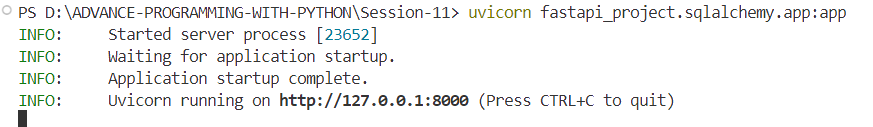

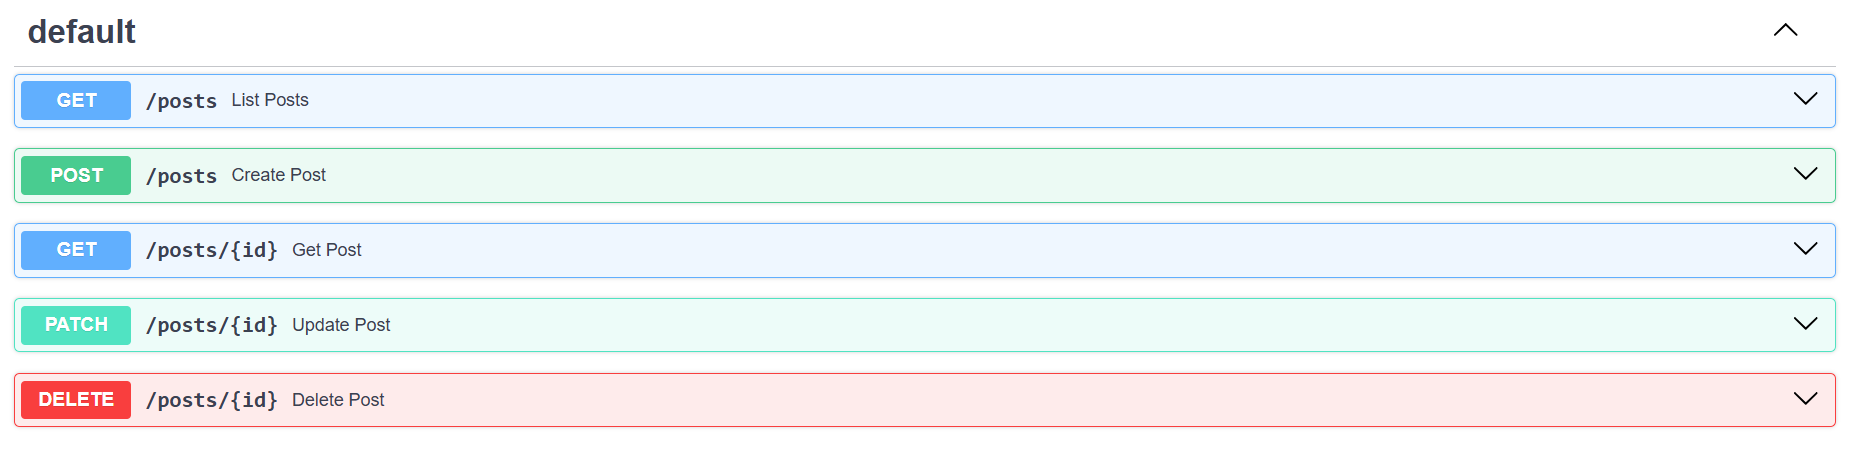

Now let's launch the FastAPI project using a SQLite database **with** relationships:

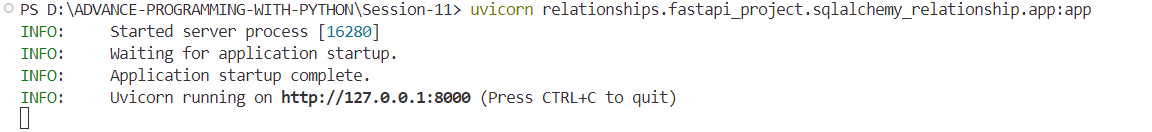

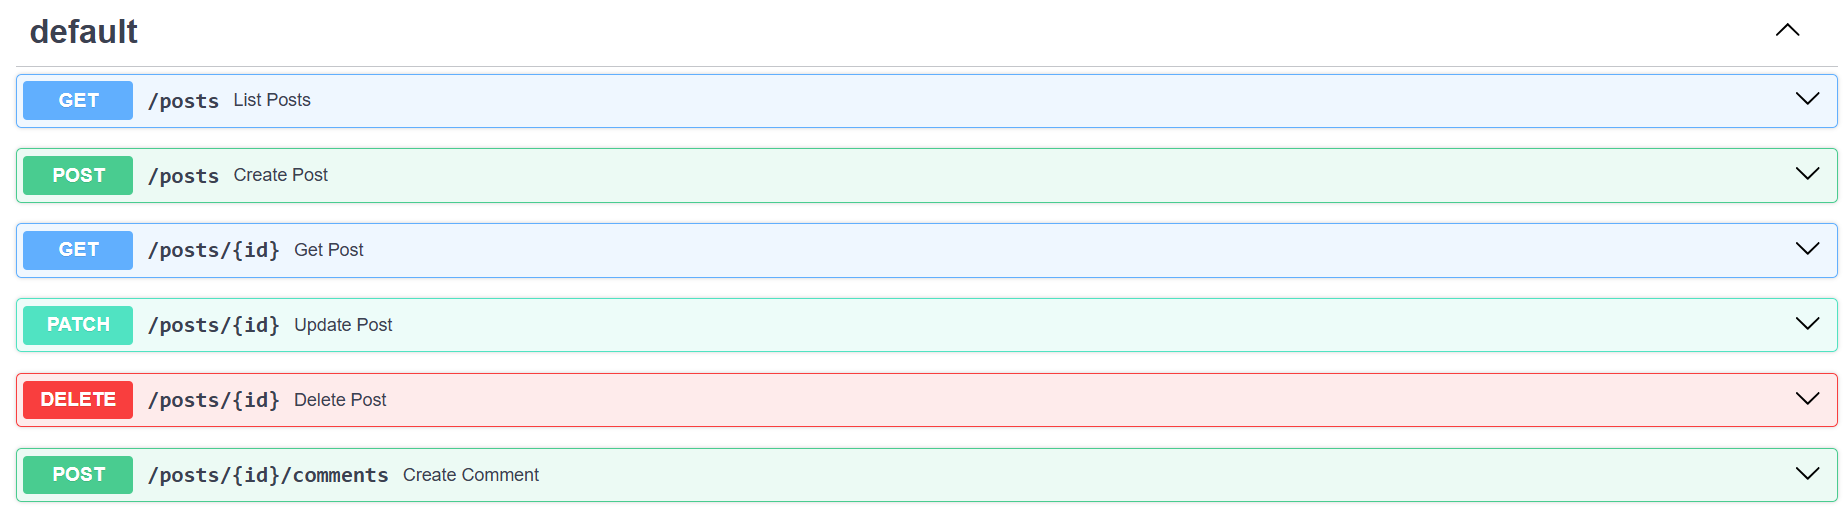